# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [14]:
# откройте данные: ваш код здесь
import pandas as pd
df = pd.read_csv('../data/spam_or_not_spam.csv')
df.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [18]:
# рассчитайте частоты для классов : ваш код здесь
print("Абсолютные частоты:\n",df['label'].value_counts())

Абсолютные частоты:
 label
0    2500
1     500
Name: count, dtype: int64


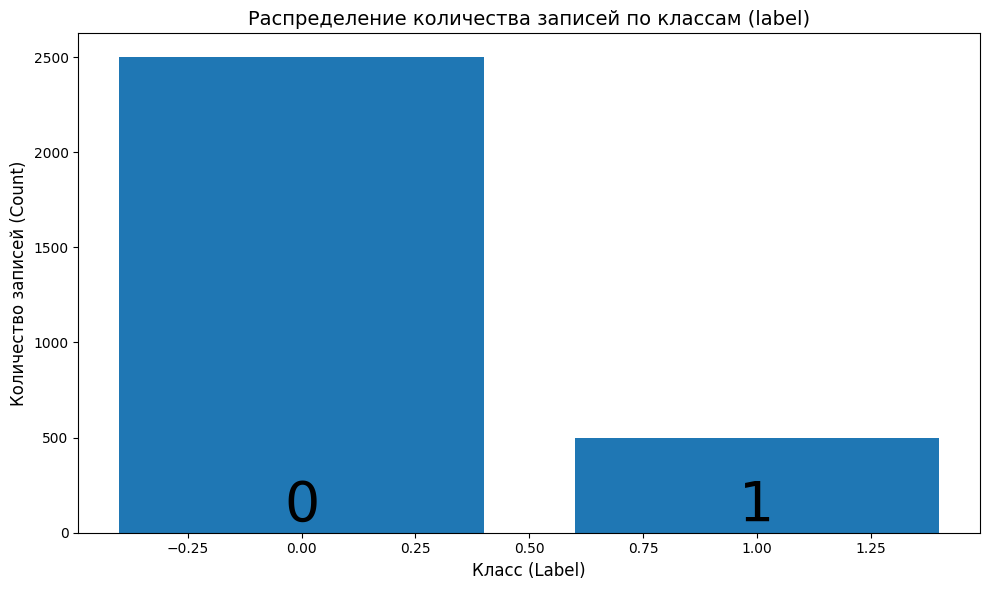

In [28]:
# визуализируйте результат: ваш код здесь
import matplotlib.pyplot as plt

class_counts = df['label'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(class_counts.index, class_counts.values)

plt.title('Распределение количества записей по классам (label)', fontsize=14)
plt.xlabel('Класс (Label)', fontsize=12)
plt.ylabel('Количество записей (Count)', fontsize=12)

for i, v in enumerate(class_counts.index):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=40)
plt.tight_layout()
plt.show()

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [ ]:
#ваш код здесь
import numpy as np
# Заменяем пустые строки и строки из пробелов на NaN
df['email'] = df['email'].astype(str).apply(lambda x: np.nan if (x.strip() == '' or x == 'nan') else x)

# Если в колонке label тоже могут быть такие проблемы (на всякий случай):
df['label'] = df['label'].astype(str).apply(lambda x: np.nan if (x.strip() == '' or x == 'nan') else x)

# Удаляем все строки, где есть пропуски (NaN) в любой из колонок
df_clean = df.dropna()

Переводим данные в векторный вид:

In [32]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df_clean["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [34]:
#ваш код здесь
print(f"В наборе данных {X.shape[1]} признаков")

В наборе данных 34116 признаков


## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [46]:
#ваш код здесь
# Переводим целевой признак к числовому типу
y = df_clean['label'].astype(int)
print(X.shape, y.shape)

(2997, 34116) (2997,)


Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [47]:
#ваш код здесь
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [62]:
#ваш код здесь
print(f"Среднее значение целевой переменной по тестовой выборке: {round(y_test.mean(),3)}")

Среднее значение целевой переменной по тестовой выборке: 0.165


## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [50]:
#ваш код здесь
from sklearn.naive_bayes import ComplementNB
clf = ComplementNB(alpha=0.01)
clf.fit(X_train, y_train)

y_test_pred = clf.predict(X_test)

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [58]:
#ваш код здесь
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

# Метрики
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

y_prob = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print("Confusion Matrix:\n", cm)
print(f"Accuracy: {acc:.3f}")
print(f"Precision (класс 1): {prec:.3f}")
print(f"Recall (класс 1): {rec:.3f}")
print(f"F1-score (класс 1): {f1:.3f}")
print(f"ROC-AUC: {auc:.3f}")

Confusion Matrix:
 [[626   0]
 [  9 115]]
Accuracy: 0.988
Precision (класс 1): 1.000
Recall (класс 1): 0.927
F1-score (класс 1): 0.962
ROC-AUC: 0.995


Нарисуйте ROC-кривую:

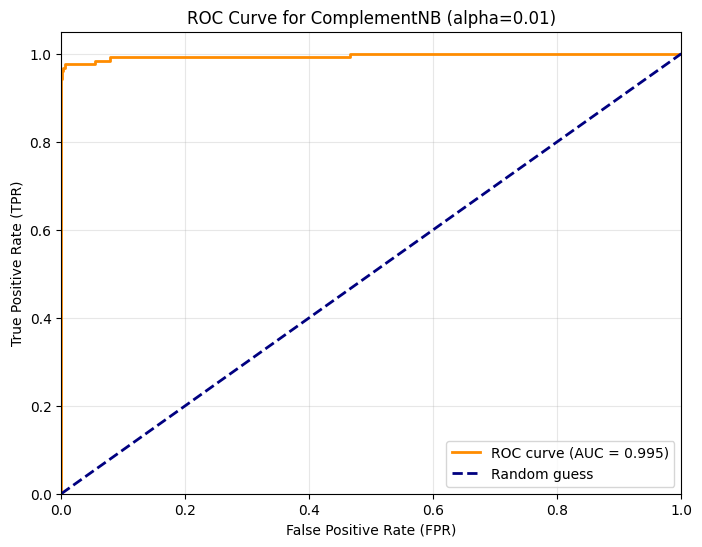

In [57]:
#ваш код здесь
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Получаем вероятности принадлежности к классу 1
y_prob = clf.predict_proba(X_test)[:, 1]

# Считаем точки ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Рисуем график
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for ComplementNB (alpha=0.01)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [59]:
#ваш код здесь
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
import numpy as np

# Диапазон alpha для перебора
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

# Стратифицированная K‑fold валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Выбираем метрику: F1 лучше отражает качество при дисбалансе
scorer = make_scorer(f1_score)

clf = ComplementNB()

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,          
    verbose=1           
)

grid_search.fit(X_train, y_train)

print("Лучший alpha:", grid_search.best_params_['alpha'])
print("Лучший F1 на кросс‑валидации:", grid_search.best_score_)

# Посмотрим результаты по всем alpha
results = grid_search.cv_results_
for alpha, mean_score, std_score in zip(
    results['param_alpha'].data,
    results['mean_test_score'],
    results['std_test_score']
):
    print(f"alpha={alpha:6.3f} | F1 mean={mean_score:.3f} ± {std_score:.3f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Лучший alpha: 0.1
Лучший F1 на кросс‑валидации: 0.9758330861025227
alpha= 0.001 | F1 mean=0.956 ± 0.013
alpha= 0.010 | F1 mean=0.967 ± 0.013
alpha= 0.100 | F1 mean=0.976 ± 0.009
alpha= 1.000 | F1 mean=0.971 ± 0.010
alpha=10.000 | F1 mean=0.444 ± 0.046


>**Выводы**: 
* Лучший alpha = 0.1, средний F1 = 0.976 при очень низкой дисперсии (±0.009). Это значит, что результат стабилен на разных фолдах — модель не «везёт», а реально выучила закономерности.
* Плавный рост от 0.001 до 0.1: с увеличением сглаживания модель становится устойчивее и лучше обобщает.
* Резкий провал при alpha = 10.0 (F1 ≈ 0.44): слишком сильное сглаживание «затирает» полезные сигналы, и модель фактически перестаёт различать классы.

Обучим итоговую модель на тренировочных данных с alpha=0.1 и оценим на тесте

In [63]:

from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

clf_best = ComplementNB(alpha=0.1)
clf_best.fit(X_train, y_train)

# Предсказания и вероятности
y_test_pred = clf_best.predict(X_test)
y_prob = clf_best.predict_proba(X_test)[:, 1]

# Метрики
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy: {acc:.3f}")
print(f"Precision (класс 1): {prec:.3f}")
print(f"Recall (класс 1): {rec:.3f}")
print(f"F1-score (класс 1): {f1:.3f}")

Accuracy: 0.995
Precision (класс 1): 0.992
Recall (класс 1): 0.976
F1-score (класс 1): 0.984
